# Code Assignment 18 — NYC COVID-19 Daily Counts (Time-Series)

**Dataset:** [NYC DOHMH — *COVID-19 Daily Counts of Cases, Hospitalizations, and Deaths*](https://data.cityofnewyork.us/Health/COVID-19-Daily-Counts-of-Cases-Hospitalizations-an/rc75-m7u3/about_data) 
**Focus:** Build a clean **daily** time series, **visualize** with resampling (month-end, yearly), **decompose** (trend/seasonality/residual), and **test stationarity** (ADF).  
**No forecasting models** and **no ACF/PACF** yet.

---

## Instructor Guidance

 Build a clean **daily** time series from NYC COVID-19 data using **SQLite** for filtering; visualize resampled views; run **decomposition** and **ADF**.

### Pseudocode Plan 
1) **Download CSV → pandas** (parse dates) → `pd.read_csv(path, parse_dates=['date_of_interest'])`  
2) **Normalize columns to lowercase** → `df.columns = df.columns.str.lower()`  
3) **Write to SQLite** → `import sqlite3; conn = sqlite3.connect('nyc_ts.db'); df.to_sql('covid_daily', conn, if_exists='replace', index=False)`  
4) **Filter to a time window** (choose recent 12–24 months, select only needed columns)   
5) **Set DateTime index & daily frequency** → `df.set_index('date_of_interest').asfreq('D')`  
6) **Pick ONE target series** (`case_count` | `hosp_count` | `death_count`) and for now fill in missing values with zero 
7) **Resample for EDA**  
   - Month-end totals → `df[[target]].resample('M').sum()`  
   - Yearly totals → use the month-end totals to figure this code out 
8) **Decompose** (weekly seasonality) → `seasonal_decompose()`  
9) **ADF test** (raw → difference)  
   - Raw → `adfuller(s.dropna())`  
   - First difference 
10) **Short write-up**: describe trend/seasonality, ADF p-values before/after differencing, and business implications.


## Your Task

### Step 0:  Run the imports below

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1:  Read in the data and look at it

In [4]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/COVID-19_Daily_Counts_of_Cases,_Hospitalizations,_and_Deaths_20251201.csv')
df

,date_of_interest,CASE_COUNT,PROBABLE_CASE_COUNT,HOSPITALIZED_COUNT,DEATH_COUNT,CASE_COUNT_7DAY_AVG,ALL_CASE_COUNT_7DAY_AVG,HOSP_COUNT_7DAY_AVG,DEATH_COUNT_7DAY_AVG,BX_CASE_COUNT,...,SI_CASE_COUNT,SI_PROBABLE_CASE_COUNT,SI_HOSPITALIZED_COUNT,SI_DEATH_COUNT,SI_PROBABLE_CASE_COUNT_7DAY_AVG,SI_CASE_COUNT_7DAY_AVG,SI_ALL_CASE_COUNT_7DAY_AVG,SI_HOSPITALIZED_COUNT_7DAY_AVG,SI_DEATH_COUNT_7DAY_AVG,INCOMPLETE
0,02/29/2020,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,03/01/2020,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,03/02/2020,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,03/03/2020,1,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,03/04/2020,5,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049,10/09/2025,108,70,4,2,121,204,16,1,18,...,3,8,1,0,7,7,14,1,0,"61,030"
2050,10/10/2025,87,54,2,0,113,189,13,1,10,...,10,6,0,0,7,7,14,1,0,"61,030"
2051,10/11/2025,69,45,1,0,109,182,11,0,15,...,3,3,0,0,6,7,13,1,0,"61,030"
2052,10/12/2025,71,37,1,0,105,174,8,0,5,...,7,1,0,0,6,7,13,1,0,"61,030"


### Step 2:  Keep needed columns & filter by time window 

- Chose any time window (use most recent data) that is 6 to 12 months long 


In [5]:
# CELL 2 — Keep needed columns & filter by date in Pandas (no SQL)
df['date_of_interest'] = pd.to_datetime(df['date_of_interest'])

# Filter most recent 9 months (can change window)
end = df['date_of_interest'].max()
start = end - pd.DateOffset(months=9)

df = df.loc[(df['date_of_interest'] >= start) & (df['date_of_interest'] <= end),
            ['date_of_interest', 'CASE_COUNT', 'HOSPITALIZED_COUNT', 'DEATH_COUNT']]

### Step 3:  Create a time series object and pick your Y (case count, hospitalized count, death count, etc)

- Use the `date_of_interest` column as your index and keep it at "Daily" frequency (try looking up set_index() in pandas)
- Fill in missing values of Y with zero 

In [9]:

df['CASE_COUNT'] = pd.to_numeric(df['CASE_COUNT'], errors='coerce')

# Build time series
ts = df.set_index('date_of_interest')['CASE_COUNT'].asfreq('D').fillna(0)


### Step 4 - Visualize the Series

<Axes: title={'center': 'Daily COVID Case Counts'}, xlabel='date_of_interest'>

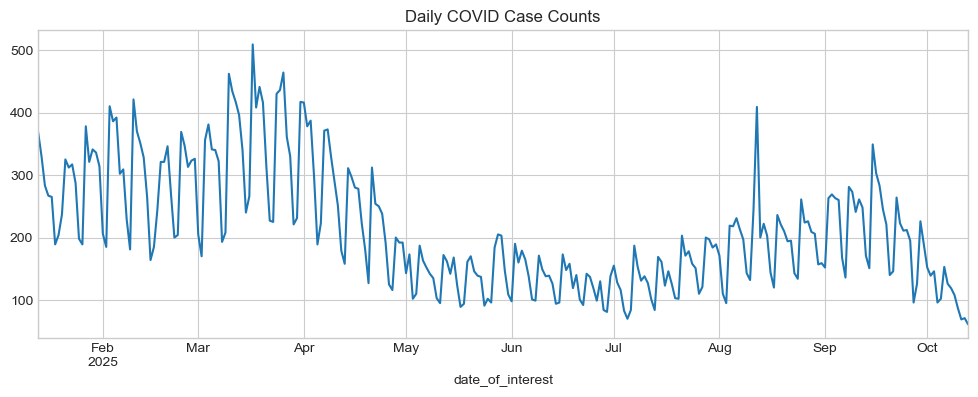

In [10]:

ts.plot(figsize=(12,4), title="Daily COVID Case Counts")


### Step 5 - Resampling EDA:  Month-end and Yearly totals 

- Use the `.resample()` function to resample the series to month end and yearly 
- Visualize both resampled series 

/var/folders/tb/3_577n455q9bf55gxv6lrs4w0000gp/T/ipykernel_93792/1548696414.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_end = ts.resample('M').sum()   # Month-end totals
/var/folders/tb/3_577n455q9bf55gxv6lrs4w0000gp/T/ipykernel_93792/1548696414.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  y_sum = ts.resample('Y').sum()   # Yearly totals


<Axes: title={'center': 'Month-End Total Cases'}, xlabel='date_of_interest'>

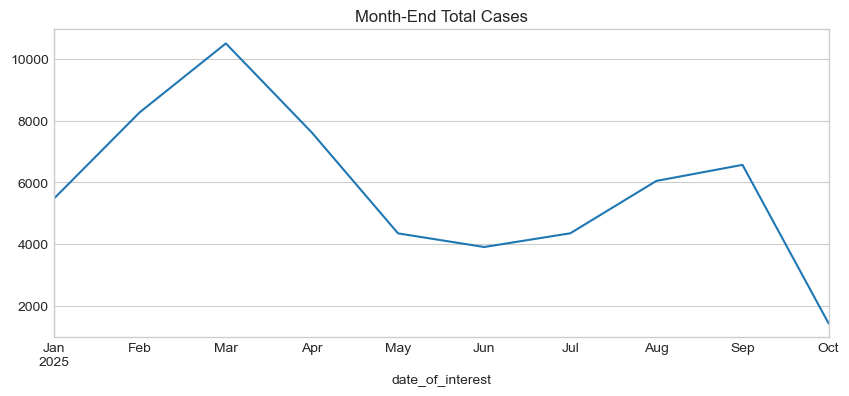

In [ ]:
# CELL 5 — Resampling EDA: Month-end and Yearly totals (Pandas-only)
m_end = ts.resample('M').sum()   # Month-end totals
y_sum = ts.resample('Y').sum()   # Yearly totals

# Visualize both
m_end.plot(figsize=(10,4), title="Month-End Total Cases")
y_sum.plot(figsize=(10,4), title="Yearly Total Cases")

### Step 6 - Decompose the original time series object (use period = 7 since that represents weekly seasonality)
- Make a visual of the decomposition

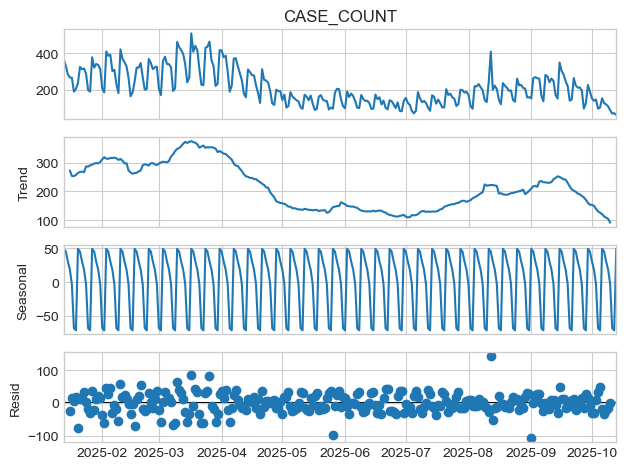

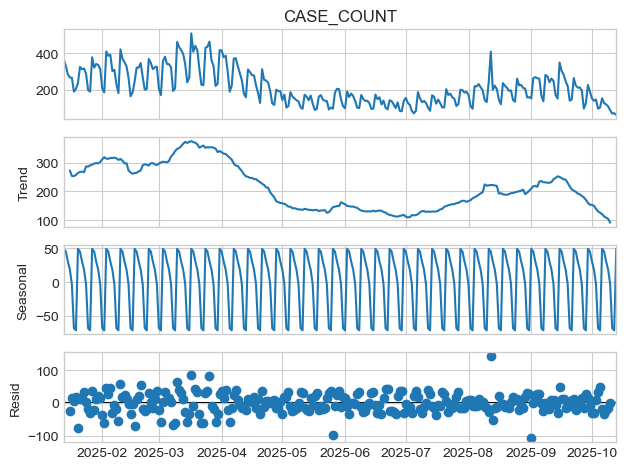

In [12]:
# CELL 6 — Decomposition (weekly seasonality → period=7)

decomp = seasonal_decompose(ts, model='additive', period=7)
decomp.plot()

### Step 7 - Do the ADF test for stationarity on the original time series and for taking a difference of 1 on the time series 
- Be sure to drop missing values (if you didn't above) 

In [13]:
# CELL 7 — ADF stationarity test: raw → difference (1) → (optional) seasonal diff(7)

print("ADF Test - Raw Series:")
print(adfuller(ts.dropna()))

print("\nADF Test - First Difference:")
ts_diff1 = ts.diff().dropna()
print(adfuller(ts_diff1))

print("\nADF Test - Seasonal Difference (lag=7):")
ts_diff_seasonal = ts.diff(7).dropna()
print(adfuller(ts_diff_seasonal))

ADF Test - Raw Series:
(np.float64(-1.2519893227037957), np.float64(0.6508412895993236), 15, 258, {'1%': np.float64(-3.455952927706342), '5%': np.float64(-2.8728086526320302), '10%': np.float64(-2.572774990685656)}, np.float64(2567.746607329169))

ADF Test - First Difference:
(np.float64(-3.326093586887541), np.float64(0.01375162602701215), 14, 258, {'1%': np.float64(-3.455952927706342), '5%': np.float64(-2.8728086526320302), '10%': np.float64(-2.572774990685656)}, np.float64(2558.6022290912993))

ADF Test - Seasonal Difference (lag=7):
(np.float64(-2.9245540687279044), np.float64(0.04256629453935772), 13, 253, {'1%': np.float64(-3.4564641849494113), '5%': np.float64(-2.873032730098417), '10%': np.float64(-2.572894516864816)}, np.float64(2501.630308305392))


## We Share — Reflection 

1) **Narrative:** One sentence describing the series over your window (trend + weekly seasonality + volatility).  
- Over the time period I looked at, COVID-19 cases start off fairly high, then slowly decrease into the spring and summer. Toward the end of the window, there’s a small bump upward again. There’s also a very clear weekly rhythm — cases spike during the week and drop on weekends — which likely reflects reporting patterns rather than true infections.
2) **Stationarity:** Which transform (if any) produced p < 0.05? Why does that matter before modeling?  
- In the raw data, the ADF p-value was 0.65, which means the original series was not stationary, and the trend and weekly patterns were still influencing the values. After applying a first difference, the p-value dropped to 0.013, which is below 0.05, so the series became stationary. A seasonal difference using a 7-day lag also worked, with a p-value of 0.043, but the first difference provided the strongest improvement. Making the data stationary is important because forecasting models generally perform better when the patterns are stable rather than drifting over time.
3) **Operational lens:** Based on month-end and yearly views, what **calendar effects** would you brief stakeholders about?
- Looking at the monthly and yearly totals, case numbers are highest in late winter and early spring, then drop off during the summer before ticking back up toward the fall. The weekly pattern also shows low weekend reporting followed by higher weekday numbers, which suggests reporting delays rather than true infection changes. 
